In [84]:
import pandas as pd

customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")

In [ ]:
df = orders.merge(order_items, on="order_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(sellers, on="seller_id", how="left")
df = df.merge(order_reviews, on="order_id", how="left")

In [86]:
df.shape
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,seller_zip_code_prefix,seller_city,seller_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,SP,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,BA,31570.0,belo horizonte,SP,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,GO,14840.0,guariba,SP,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,RN,31842.0,belo horizonte,MG,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,SP,8752.0,mogi das cruzes,SP,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [87]:
order_volume = order_items.groupby("order_id").size().reset_index(name="order_volume")

df = df.merge(order_volume, on="order_id", how="left")

In [88]:
import pandas as pd

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_carrier_date"] = pd.to_datetime(df["order_delivered_carrier_date"])

df["warehouse_processing_time_hours"] = (
    df["order_delivered_carrier_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

In [89]:
geo_avg = geolocation.groupby("geolocation_zip_code_prefix").agg({
    "geolocation_lat": "mean",
    "geolocation_lng": "mean"
}).reset_index()

In [90]:
df = df.merge(
    geo_avg,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

df = df.rename(columns={
    "geolocation_lat": "cust_lat",
    "geolocation_lng": "cust_lng"
})

In [ ]:
df = df.merge(
    geo_avg,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

df = df.rename(columns={
    "geolocation_lat": "seller_lat",
    "geolocation_lng": "seller_lng"
})

In [92]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["shipment_distance_km"] = haversine(
    df["cust_lat"], df["cust_lng"],
    df["seller_lat"], df["seller_lng"]
)

In [93]:
df["order_delivered_customer_date"] = pd.to_datetime(
    df["order_delivered_customer_date"]
)

df["delivery_time_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

In [94]:
df["speed_km_per_day"] = df["shipment_distance_km"] / df["delivery_time_days"]

df["traffic_condition"] = pd.cut(
    df["speed_km_per_day"],
    bins=[0, 50, 150, 10000],
    labels=["Heavy", "Moderate", "Light"]
)

In [95]:
df["month"] = df["order_purchase_timestamp"].dt.month

def weather(m):
    if m in [12, 1, 2]:
        return "Rainy"
    elif m in [6, 7, 8]:
        return "Cool"
    else:
        return "Normal"

df["weather_indicator"] = df["month"].apply(weather)


In [96]:
df["order_estimated_delivery_date"] = pd.to_datetime(
    df["order_estimated_delivery_date"]
)

df["on_time_flag"] = (
    df["order_delivered_customer_date"]
    <= df["order_estimated_delivery_date"]
).astype(int)

In [97]:
seller_perf = df.groupby("seller_id")["on_time_flag"].mean().reset_index()
seller_perf.rename(columns={"on_time_flag": "seller_on_time_rate"}, inplace=True)

df = df.merge(seller_perf, on="seller_id", how="left")

In [98]:
delay_days = (
    df["order_delivered_customer_date"]
    - df["order_estimated_delivery_date"]
).dt.days

def classify(d):
    if d <= 0:
        return "On-Time"
    elif d <= 3:
        return "At-Risk"
    else:
        return "Delayed"

df["delivery_status"] = delay_days.apply(classify)

In [99]:
df[[
    "order_volume",
    "warehouse_processing_time_hours",
    "shipment_distance_km",
    "traffic_condition",
    "weather_indicator",
    "seller_on_time_rate",
    "delivery_status"
]].head()

,order_volume,warehouse_processing_time_hours,shipment_distance_km,traffic_condition,weather_indicator,seller_on_time_rate,delivery_status
0,1.0,56.974167,18.576110,Heavy,Normal,1.000000,On-Time
1,1.0,41.823056,851.495069,Moderate,Cool,0.976190,On-Time
2,1.0,5.186389,514.410666,Moderate,Cool,0.878028,On-Time
3,1.0,90.198056,1822.226336,Moderate,Normal,0.923077,On-Time
4,1.0,22.465278,29.676625,Heavy,Rainy,0.816092,On-Time


In [100]:
final_df = df[[
    "order_volume",
    "warehouse_processing_time_hours",
    "shipment_distance_km",
    "traffic_condition",
    "weather_indicator",
    "seller_on_time_rate",
    "delivery_time_days",
    "delivery_status"
]]

In [101]:
final_df.shape

(114092, 8)

In [102]:
X = final_df.drop("delivery_status", axis=1)
y = final_df["delivery_status"]

In [103]:
X = pd.get_dummies(X, drop_first=True)

In [104]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)

['At-Risk' 'Delayed' 'On-Time']


In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [106]:
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

In [ ]:
import pandas as pd

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())
print("\nPercentage:")
print(pd.Series(y_train).value_counts(normalize=True))

In [107]:
from imblearn.over_sampling import SMOTE

# Balance only minority classes up to second largest class
sm = SMOTE(sampling_strategy='not majority', random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [83]:
print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print("\nPercentage:")
print(pd.Series(y_train_sm).value_counts(normalize=True))


After SMOTE:
2    82835
1    82835
0    82835
Name: count, dtype: int64

Percentage:
2    0.333333
1    0.333333
0    0.333333
Name: proportion, dtype: float64


<Figure size 640x480 with 0 Axes>

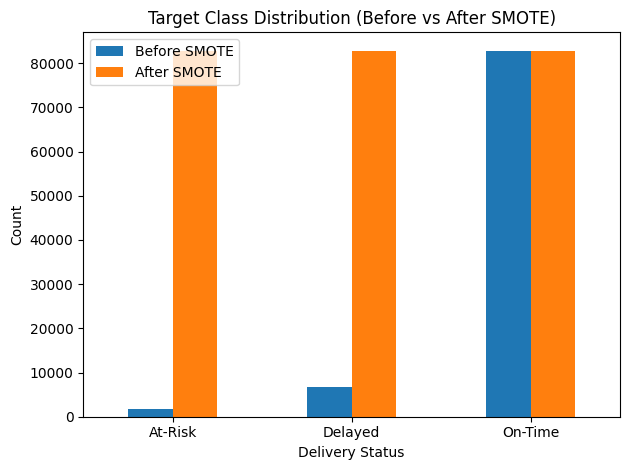

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# Get readable class names
class_labels = le.classes_   # ['At-Risk', 'Delayed', 'On-Time']

# Count values
before = pd.Series(y_train).value_counts().sort_index()
after = pd.Series(y_train_sm).value_counts().sort_index()

# Replace numeric index with actual class names
before.index = class_labels
after.index = class_labels

# Combine into one DataFrame
df_plot = pd.DataFrame({
    "Before SMOTE": before,
    "After SMOTE": after
})

# Plot
plt.figure()
df_plot.plot(kind='bar')
plt.title("Target Class Distribution (Before vs After SMOTE)")
plt.xlabel("Delivery Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn
}

results = []

for name, y_pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted")
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Accuracy", ascending=False)
results_df



,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.949384,0.955509,0.949384,0.952076
0,Decision Tree,0.938034,0.947753,0.938034,0.942310
3,KNN,0.888952,0.946429,0.888952,0.912351
2,Logistic Regression,0.783295,0.908502,0.783295,0.835113


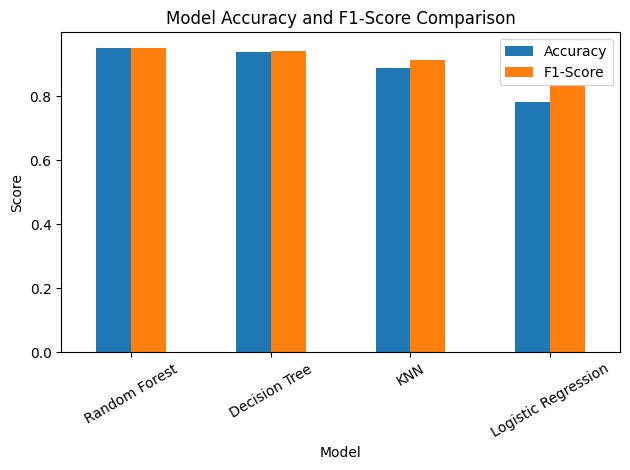

In [114]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "F1-Score"]].plot(kind="bar")
plt.ylabel("Score")
plt.title("Model Accuracy and F1-Score Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [36]:
best_model_row = results_df.iloc[0]
print(f"The best performing model is {best_model_row['Model']} "
      f"with an accuracy of {best_model_row['Accuracy']:.4f}.")

The best performing model is Random Forest with an accuracy of 0.9494.


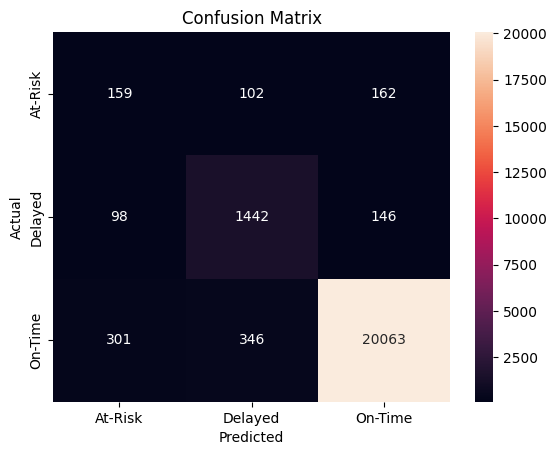

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf,   # replace with best model
    target_names=le.classes_
))

              precision    recall  f1-score   support

     At-Risk       0.28      0.38      0.32       423
     Delayed       0.76      0.86      0.81      1686
     On-Time       0.98      0.97      0.98     20710

    accuracy                           0.95     22819
   macro avg       0.68      0.73      0.70     22819
weighted avg       0.96      0.95      0.95     22819



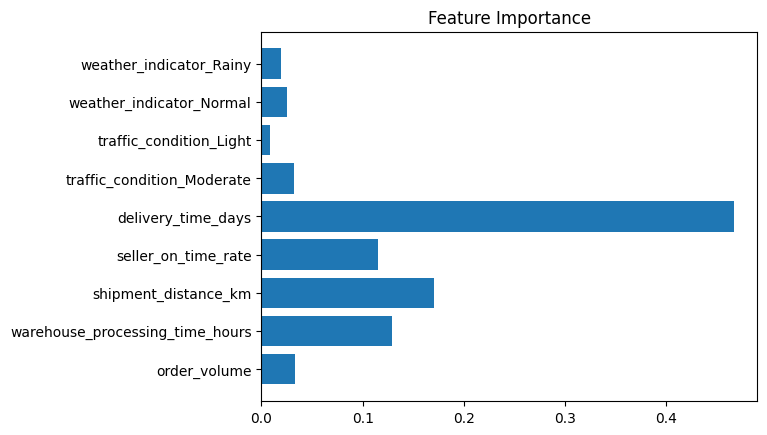

In [39]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [40]:
y_prob = rf.predict_proba(X_test)

In [41]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

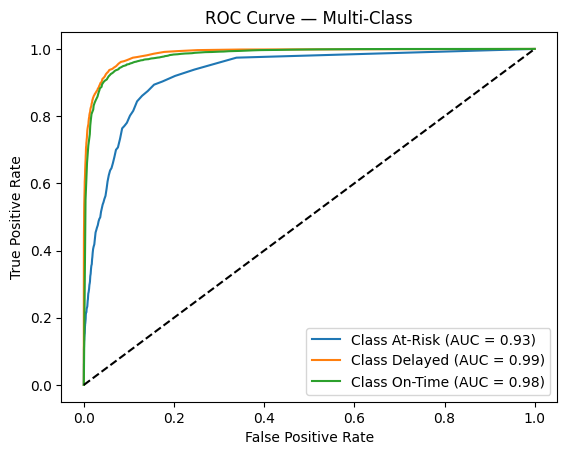

In [42]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

n_classes = y_test_bin.shape[1]

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"Class {le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Multi-Class")
plt.legend()
plt.show()

In [43]:
from sklearn.metrics import roc_auc_score

overall_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr"
)

print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 0.9647981588696579
